Testing MLR / PCR / PLS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sk

last datasettet med load_diabetes(as_frame=True)
hent ut X (prediktorer) og y (target)

In [6]:
diabetes = sk.datasets.load_diabetes(as_frame=True)


Sjekk X.describe() og y.describe() for å forstå skala og fordeling. Sjekk X.corr() eller lag et heatmap for å se kollinearitet mellom prediktorene — dette blir relevant når du senere sammenligner med PCR og PLS.

In [8]:
X = diabetes.data
y = diabetes.target
print(X.describe())
print("__________________________________________________________")
print(y.describe())

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.268604e-17  1.130318e-17  
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761

In [9]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

Skalering er vanligvis ikke strengt nødvendig for MLR, i motsetning til PCR/PLS der skala påvirker komponentene direkte. Du kan vurdere StandardScaler for å gjøre koeffisientene mer sammenlignbare, men det er ikke påkrevd her.

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 37.9 ,-241.96, 542.43,..., 275.32, 736.2 , 48.67]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['age','sex','bmi',...,'s4','s5','s6']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


plot dataene med modellen

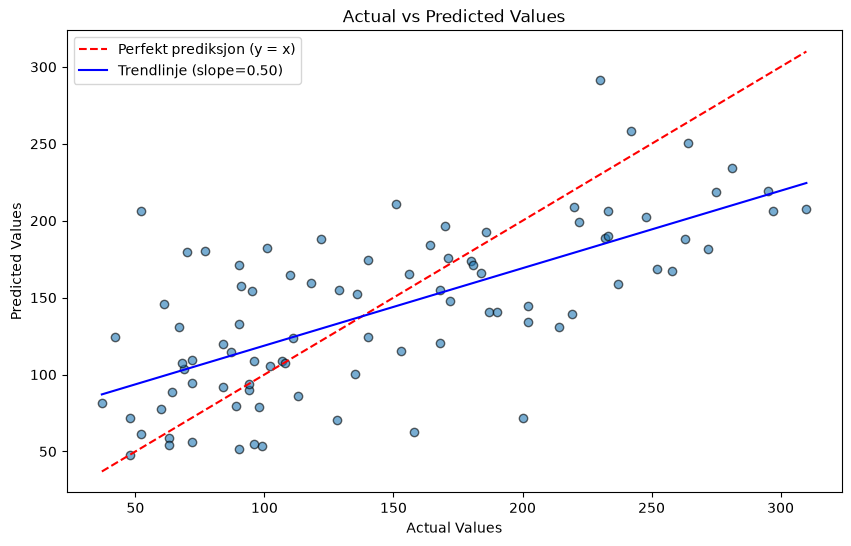

In [18]:
import numpy as np

y_pred = model.predict(X_test)

# Fit en lineær trendlinje gjennom (y_test, y_pred)-punktene
coeffs = np.polyfit(y_test, y_pred, deg=1)  # deg=1 => rett linje
trendline = np.poly1d(coeffs)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor='k')

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]
plt.plot(lims, lims, 'r--', label='Perfekt prediksjon (y = x)')

x_vals = np.linspace(lims[0], lims[1], 100)
plt.plot(x_vals, trendline(x_vals), 'b-', label=f'Trendlinje (slope={coeffs[0]:.2f})')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()

plt.show()

In [19]:
residuals = y_test - model.predict(X_test)

print("Gjennomsnittlig avvik:", residuals.mean())
print("Gjennomsnittlig absolutt avvik (MAE):", abs(residuals).mean())
print("Root Mean Squared Error (RMSE):", (residuals**2).mean()**0.5)

Gjennomsnittlig avvik: 3.912840375077802
Gjennomsnittlig absolutt avvik (MAE): 42.79409467959994
Root Mean Squared Error (RMSE): 53.85344583676592


PCR

In [ ]:
# standardize the data and create the covariance matrix from the original data

scaler = sk.preprocessing.StandardScaler()

X_std = scaler.fit_transform(X)

n_samples = X_std.shape[0]
cov_matrix = (X_std.T @ X_std) / (n_samples - 1)

print("Covariance matrix shape:", cov_matrix.shape)
print(cov_matrix[:5, :5])

cov_matrix_np = np.cov(X_std, rowvar=False)
print("Matches np.cov()?", np.allclose(cov_matrix, cov_matrix_np))



Covariance matrix shape: (10, 10)
[[1.00226757 0.17413106 0.18550436 0.33618819 0.26065053]
 [0.17413106 1.00226757 0.08836131 0.241557   0.03535681]
 [0.18550436 0.08836131 1.00226757 0.39630752 0.25034381]
 [0.33618819 0.241557   0.39630752 1.00226757 0.24301383]
 [0.26065053 0.03535681 0.25034381 0.24301383 1.00226757]]
Matches np.cov()? True


In [25]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("All eigenvalues:")
print(eigenvalues)

All eigenvalues:
[4.03333594 1.49570362 1.20870088 0.95764302 0.66368294 0.60408378
 0.53778235 0.43466544 0.07849762 0.00858014]


Text(0.5, 1.0, 'Eigenvalues of the Covariance Matrix')

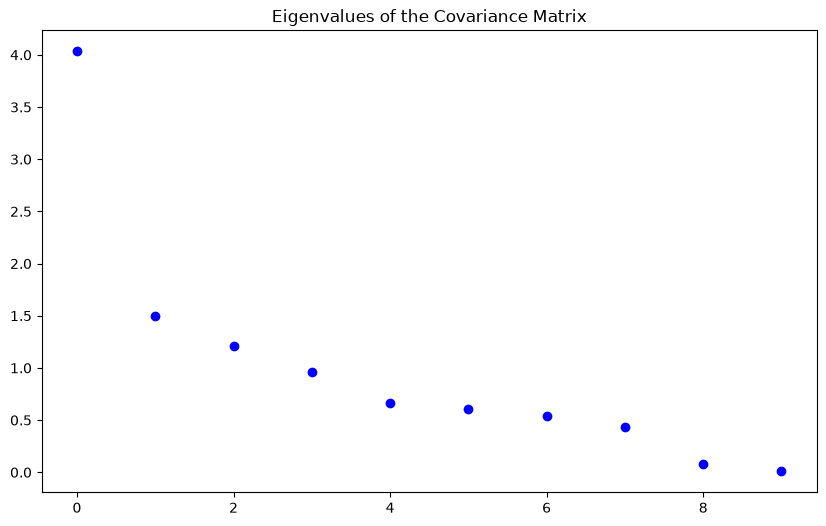

In [34]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(eigenvalues)), eigenvalues, color='blue', label='Eigenvalues', marker='o')
plt.title("Eigenvalues of the Covariance Matrix")

finn og marker kneedle kneet

Knee ved PC: 2


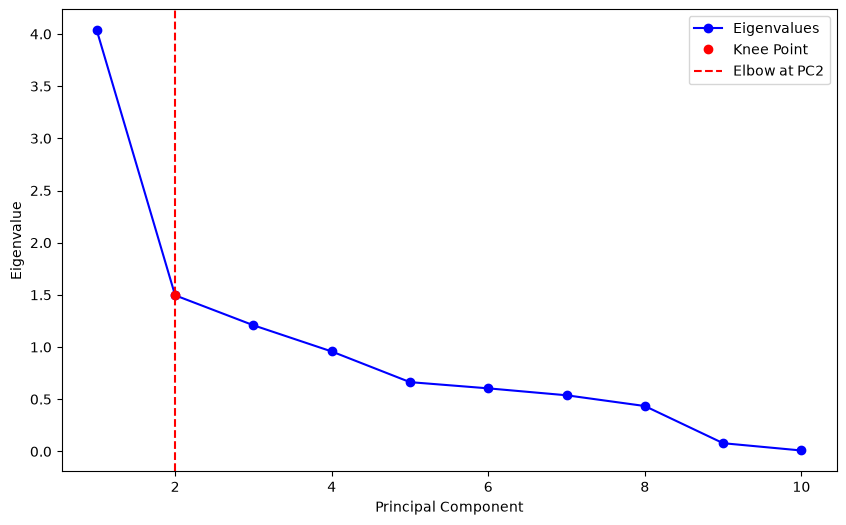

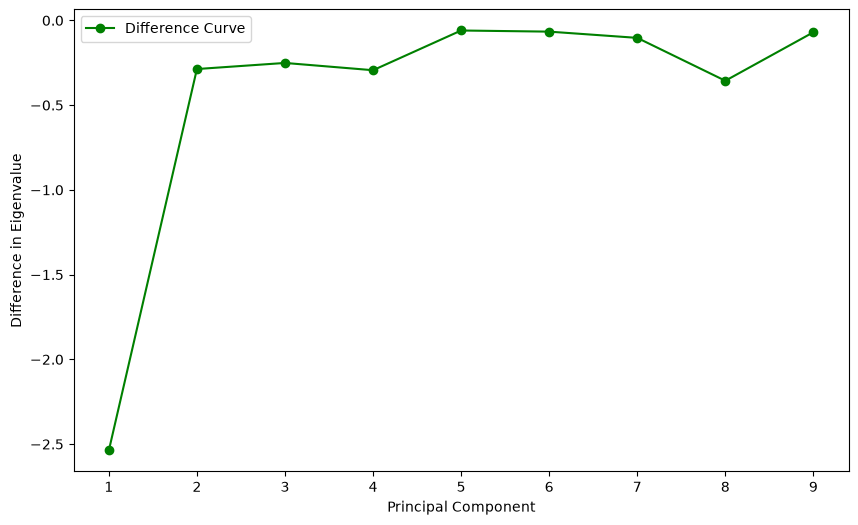

In [61]:


import kneed


knee = kneed.KneeLocator(range(len(eigenvalues)), eigenvalues, curve='convex', direction='decreasing')

k = knee.knee + 1  # +1 fordi knee.knee er 0-indeksert, men PC-nummer starter på 1
print("Knee ved PC:", k)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'bo-', label='Eigenvalues')
plt.plot(k, eigenvalues[knee.knee], 'ro', label='Knee Point')
plt.axvline(x=k, color='red', linestyle='--', label=f'Elbow at PC{k}')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.legend()
plt.show()

difference_curve = np.diff(eigenvalues)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(difference_curve) + 1), difference_curve, 'go-', label='Difference Curve')
plt.xlabel('Principal Component')
plt.ylabel('Difference in Eigenvalue')
plt.legend()
plt.show()


explain variance by first 2 PCs

In [75]:
variance_explained = eigenvalues / np.sum(eigenvalues)
print("Variance explained by the first 2 principal components:", np.sum(variance_explained[:2]))
print("Variance explained by the first 3 principal components:", np.sum(variance_explained[:3]))
print("Variance explained by the first 4 principal components:", np.sum(variance_explained[:4]))
print("Variance explained by the first 5 principal components:", np.sum(variance_explained[:5]))
print("Variance explained by the first 6 principal components:", np.sum(variance_explained[:6]))

Variance explained by the first 2 principal components: 0.5516530427751478
Variance explained by the first 3 principal components: 0.672249668687648
Variance explained by the first 4 principal components: 0.7677973090140595
Variance explained by the first 5 principal components: 0.834015448140677
Variance explained by the first 6 principal components: 0.8942871557026896


Keeping 6 PCs

In [91]:
k = 6
X_train_pcr, X_test_pcr = X_train @ eigenvectors[:, :k], X_test @ eigenvectors[:, :k]

model_pcr = LinearRegression()

model_pcr.fit(X_train_pcr, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-448.77, 290.91,-261.63,-579.25, -42.87,-232.32]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[1.78,1.08,1. ,0.89,0.72,0.69]"


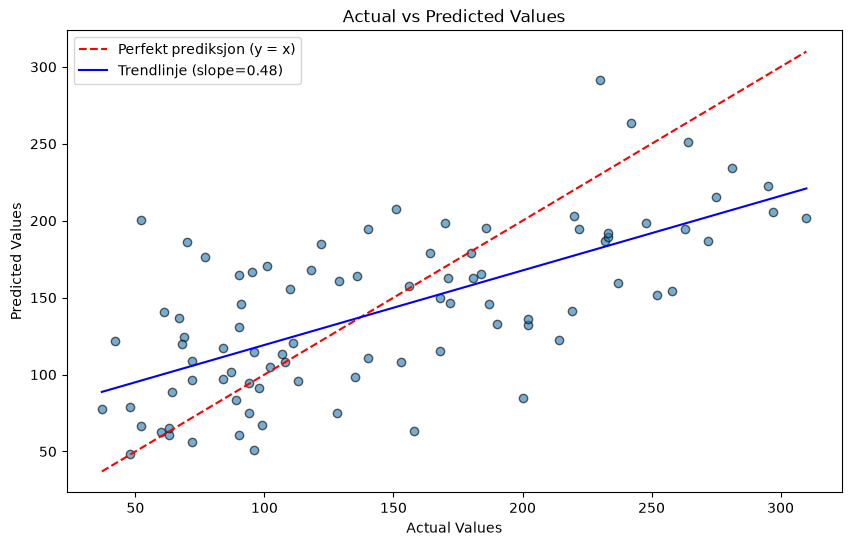

In [92]:
y_pred_pcr = model_pcr.predict(X_test_pcr)

# Fit en lineær trendlinje gjennom (y_test, y_pred)-punktene
coeffs = np.polyfit(y_test, y_pred_pcr, deg=1)  # deg=1 => rett linje
trendline = np.poly1d(coeffs)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_pcr, alpha=0.6, edgecolor='k')

lims = [
    min(y_test.min(), y_pred_pcr.min()),
    max(y_test.max(), y_pred_pcr.max())
]
plt.plot(lims, lims, 'r--', label='Perfekt prediksjon (y = x)')

x_vals = np.linspace(lims[0], lims[1], 100)
plt.plot(x_vals, trendline(x_vals), 'b-', label=f'Trendlinje (slope={coeffs[0]:.2f})')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()

plt.show()

In [93]:
residuals = y_test - model_pcr.predict(X_test_pcr)

print("Gjennomsnittlig avvik:", residuals.mean())
print("Gjennomsnittlig absolutt avvik (MAE):", abs(residuals).mean())
print("Root Mean Squared Error (RMSE):", (residuals**2).mean()**0.5)

Gjennomsnittlig avvik: 4.349492644508458
Gjennomsnittlig absolutt avvik (MAE): 43.80213898939065
Root Mean Squared Error (RMSE): 54.526075650956095


PLS

Partial Least Squares Regression (PLSR) finner latente komponenter (scores) som maksimerer kovariansen mellom prediktorene X og responsen y, i motsetning til PCA/PCR som kun maksimerer variansen i X.

Første komponent finnes ved å søke etter en vektvektor w som løser:

maksimer  cov(X·w, y)²   gitt at  ||w|| = 1

Dette gir en score-vektor:

t = X · w

som representerer den retningen i X-rommet som er mest relevant for å predikere y.

Etter at komponent 1 er funnet, "deflateres" X og y — det vil si at informasjonen forklart av t1 trekkes fra, og prosessen gjentas for å finne neste komponent t2, og så videre, til man har k komponenter.

I praksis brukes en algoritme kalt NIPALS til å beregne dette iterativt, men det viktige konseptuelle poenget er: PLS-komponentene er styrt av y fra start, mens PCA-komponentene er det ikke. Dette er grunnen til at PLS ofte trenger færre komponenter enn PCR for å oppnå samme eller bedre prediksjonsevne.

Til slutt gjøres en vanlig lineær regresjon av y på disse k komponentene (t1, ..., tk), akkurat som i PCR.

Akkurat som PCA, er PLS skala-sensitiv siden den bygger komponenter basert på kovarians, som påvirkes av variablenes skala. Bruk samme skalerte data som du laget til PCR (X_train_scaled, X_test_scaled) — ingen ny skalering nødvendig hvis du allerede har disse fra PCR-delen.

Markdown-celle: Steg 2 — Velg antall komponenter og tren modellen

I motsetning til PCR, hvor du valgte antall komponenter basert på forklart varians i X (scree-plot), velger man i PLS ofte antall komponenter basert på prediksjonsytelse — f.eks. med kryssvalidering, hvor du tester ulike antall komponenter og ser hvilken gir lavest feil. For nå, start enkelt: velg et fast antall komponenter (f.eks. samme antall som du testet i PCR, som 3 eller 6) slik at du kan sammenligne direkte.

RMSE for 1 komponenter: 60.4890
RMSE for 2 komponenter: 55.4385
RMSE for 3 komponenter: 55.3309
RMSE for 4 komponenter: 55.3805
RMSE for 5 komponenter: 55.3999
RMSE for 6 komponenter: 55.7173
RMSE for 7 komponenter: 55.8083
RMSE for 8 komponenter: 55.4605
RMSE for 9 komponenter: 55.3759
RMSE for 10 komponenter: 55.3475
Indeks for minimum RMSE: 3


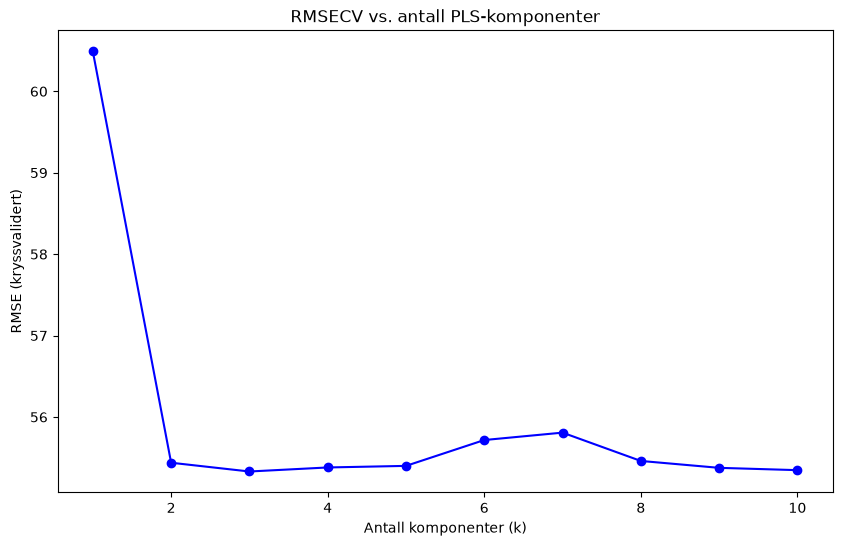

In [ ]:
from sklearn.datasets import load_diabetes
data = load_diabetes(as_frame=True)
X = data.data
y = data.target

# Del i trening og test (samme split brukes gjennom hele oppgaven for rettferdig sammenligning)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Skaler X (sentrere og skalere til enhetsvarians) -- nødvendig for PCA og PLS, men ikke MLR
# Fit scaler KUN på treningsdata, deretter transform begge (unngå data leakage)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score



max_components = 10
rmse_per_k = []

for k in range(1, max_components + 1):
    pls_model = PLSRegression(n_components=k)
    
    scores = cross_val_score(
        pls_model, X_train_scaled, y_train,
        scoring='neg_mean_squared_error', cv=20
    )
    
    rmse = np.sqrt(-scores.mean())
    rmse_per_k.append(rmse)

for i in rmse_per_k:
    print(f"RMSE for {rmse_per_k.index(i)+1} komponenter: {i:.4f}")
    print(f"Indeks for minimum RMSE: {rmse_per_k.index(min(rmse_per_k)) + 1}")


plt.figure(figsize=(10, 6))
plt.plot(range(1, max_components + 1), rmse_per_k, 'bo-')
plt.xlabel("Antall komponenter (k)")
plt.ylabel("RMSE (kryssvalidert)")
plt.title("RMSECV vs. antall PLS-komponenter")
plt.show()


In [124]:
k = 3

pls_model = PLSRegression(n_components=k)
pls_model.fit(X_train_scaled, y_train)

# residuals:

residuals = y_test - pls_model.predict(X_test_scaled)
MAE = np.mean(np.abs(residuals))
RMSE = np.sqrt(np.mean(residuals**2))
print(f"MAE: {MAE:.4f}")
print(f"RMSE: {RMSE:.4f}")


MAE: 42.8752
RMSE: 53.4807


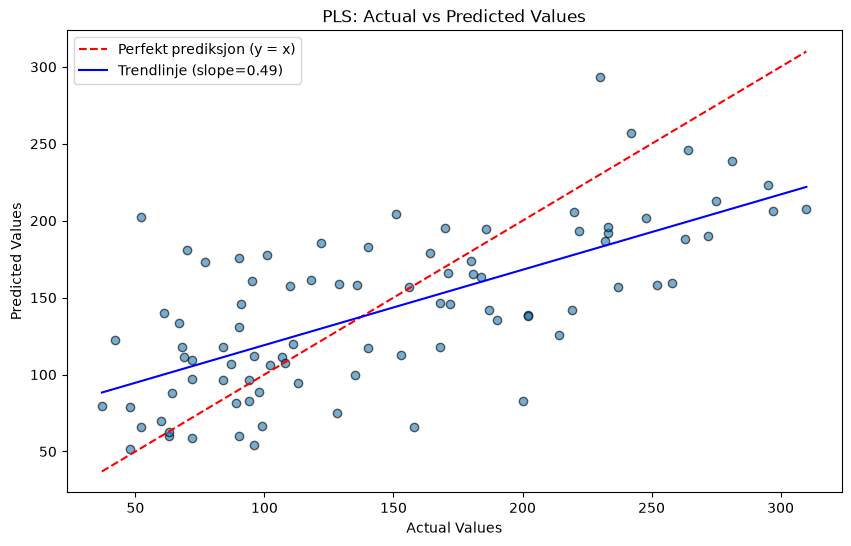

In [125]:
y_pred_pls = pls_model.predict(X_test_scaled).ravel()

coeffs = np.polyfit(y_test, y_pred_pls, deg=1)
trendline = np.poly1d(coeffs)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_pls, alpha=0.6, edgecolor='k')

lims = [
    min(y_test.min(), y_pred_pls.min()),
    max(y_test.max(), y_pred_pls.max())
]
plt.plot(lims, lims, 'r--', label='Perfekt prediksjon (y = x)')

x_vals = np.linspace(lims[0], lims[1], 100)
plt.plot(x_vals, trendline(x_vals), 'b-', label=f'Trendlinje (slope={coeffs[0]:.2f})')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("PLS: Actual vs Predicted Values")
plt.legend()

plt.show()